In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, RepeatedKFold, cross_val_score
from sklearn.linear_model import Ridge

In [2]:
train_df = pd.read_csv("stock_2_train.csv")

In [3]:
train_df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,target
0,1.749549,1.379060,1.466218,-0.040868,-1.289326,2.482270,0.062953,1.228708,-0.550275,-2.562374,1.470103,0.449527,0.329788,0.182796,-1.637142,124.306905
1,-2.183235,1.022913,0.350338,0.310195,0.303455,-2.060162,-0.985166,-0.451727,-0.748743,0.982296,1.143162,1.303832,-1.210172,-0.968907,0.049078,299.009603
2,1.439336,0.164688,-0.248423,-1.783725,-1.619735,-1.835699,0.379339,-1.362249,1.255577,-1.683831,-0.597999,-0.035882,0.335943,0.075771,-0.517127,244.389408
3,-0.138912,0.848406,0.554161,-0.748682,0.136699,1.490442,-0.831366,0.145167,-0.193161,-0.732599,0.864937,0.693117,-1.050654,0.071236,0.031818,195.727263
4,-0.632556,1.872235,-0.047678,1.768425,-1.398392,0.518185,2.071083,0.029751,-0.264004,-1.450831,2.048307,1.893192,2.120943,1.697403,-1.377064,264.674971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,-0.271592,1.541580,0.467276,-1.288850,1.095383,-0.891514,0.743359,0.553165,0.616310,0.440584,1.043551,1.391736,-0.247780,0.896610,1.181075,293.261550
1495,0.988532,0.475438,-0.624721,0.182097,0.572287,0.047053,0.480243,-0.862951,1.992832,-1.025807,1.549324,1.093389,0.639595,-0.385795,1.167205,277.517177
1496,-0.317563,-0.441448,0.762197,-1.770736,1.574280,0.135529,0.610018,0.725078,-0.708059,2.291798,-1.913030,-1.458059,1.316276,1.553349,0.811855,188.538130
1497,-1.639221,-1.199935,0.299057,0.618715,-0.283385,0.892606,-0.796554,-0.399692,-0.302078,0.992037,-0.913405,-1.080435,-0.423477,-1.431358,-0.052105,192.548273


Only 1500 rows.

In [4]:
X = train_df.drop(columns=['target'])
y = train_df['target']

model = LinearRegression().fit(X, y)

predictions = model.predict(X)
r2 = r2_score(y, predictions)
print(f"R2 Score: {r2:.4f}")

mae = mean_absolute_error(y, predictions)
print(f"Mean Absolute Error: {mae:.4f}")

rmse = np.sqrt(mean_squared_error(y, predictions))
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.9611
Mean Absolute Error: 7.6257
RMSE: 9.5917


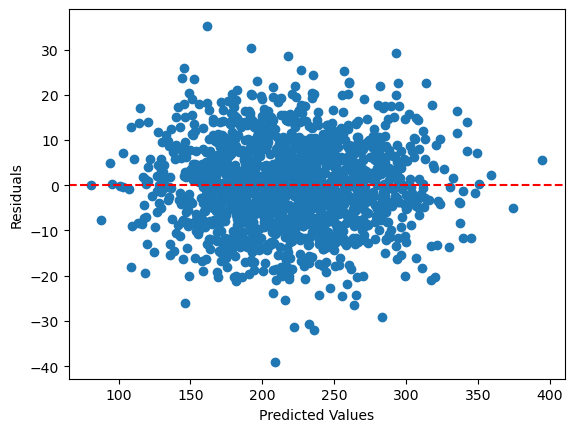

In [5]:
residuals = y - model.predict(X)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

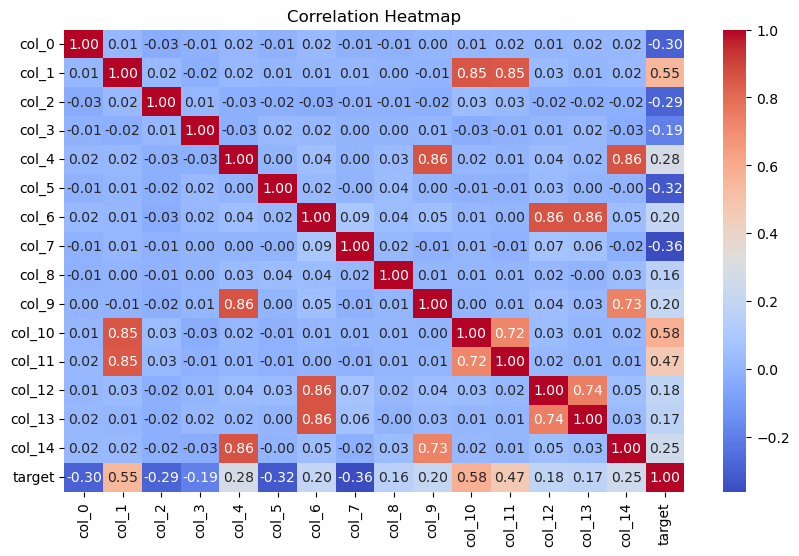

In [6]:
corr = train_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Problem with multicollinearity as variables are correlated with each other - makes the linear regression unstable. A simple regression cannot understand if the variance is coming from one predictor or another. We can use a ridge/lasso regression to account for this.

In [7]:
# Setup the model and cross-validation
model = ElasticNet(max_iter=10000)
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Define the grid: 
# l1_ratio close to 1 is like Lasso (drops vars), close to 0 is like Ridge
grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
}

search = GridSearchCV(estimator=model, param_grid=grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
results = search.fit(X, y)

print(f"Best Params: {results.best_params_}")

Best Params: {'alpha': 0.01, 'l1_ratio': 1.0}


In [8]:
# Get the coefficients from the best model
best_model = search.best_estimator_
features = X.columns # Assuming X is your dataframe

# Create a summary table
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': best_model.coef_})

# Filter for the survivors
survivors = coef_df[coef_df['Coefficient'] != 0]
dropped = coef_df[coef_df['Coefficient'] == 0]

print(f"Lasso kept {len(survivors)} features and dropped {len(dropped)}.")
print("\nDropped Features:")
print(dropped['Feature'].values)

Lasso kept 15 features and dropped 0.

Dropped Features:
[]


In [9]:
for col, coef in zip(train_df.columns, best_model.coef_):
    print(f"{col}: {coef:10.4f}")

col_0:   -16.0765
col_1:    11.7444
col_2:   -15.1046
col_3:    -7.7646
col_4:    17.0721
col_5:   -16.5675
col_6:    10.7166
col_7:   -19.4682
col_8:     7.2319
col_9:    -4.6103
col_10:    15.8755
col_11:    -0.2898
col_12:    -0.1696
col_13:     0.0009
col_14:    -0.7458


In [10]:
ghost_cols = ['col_11', 'col_12', 'col_13']

X_lean = X.drop(columns=ghost_cols)

lean_model = LinearRegression()
lean_model.fit(X_lean, y)

# Step 3: Check the new R-squared
y_pred_lean = lean_model.predict(X_lean)
new_r2 = r2_score(y, y_pred_lean)

print(f"Original R-squared (15 features): 0.96")
print(f"Lean R-squared ({len(X_lean.columns)} features): {new_r2:.4f}")

Original R-squared (15 features): 0.96
Lean R-squared (12 features): 0.9610


In [11]:
drop_cols = ['col_11', 'col_12', 'col_13']
lean_df = train_df.drop(columns=drop_cols)

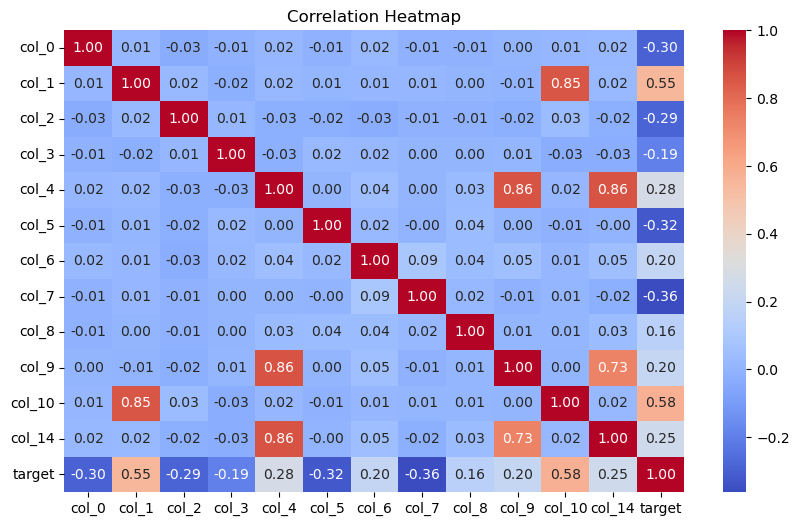

In [12]:
corr = lean_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

column 1 and column 10 are correlated and both have a similar correlation with the target variable. Column 4, 9 and 14 are all correlated as well.

In [13]:
# The "Minimalist" Feature Set
super_lean_cols = X_lean.drop(columns=['col_1', 'col_9', 'col_14'])

# Fit and Check
minimal_model = LinearRegression()
minimal_model.fit(super_lean_cols, y)
print(f"Minimal R-squared ({len(super_lean_cols.columns)} features): {minimal_model.score(super_lean_cols, y):.4f}")

Minimal R-squared (9 features): 0.9425


r squared dropped 2% after removing highly correlate feature 1,9 and 14, indicating these features must add some valuable insights

In [14]:
# Use the 12-feature set that gave you 0.9610
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_lean, y)

print(f"Ridge R-squared (12 features): {ridge_model.score(X_lean, y):.4f}")

Ridge R-squared (12 features): 0.9610


In [15]:
# Assuming ridge_model is your fitted Ridge(alpha=1.0)
for col, coef in zip(X_lean.columns, ridge_model.coef_):
    print(f"{col:10}: {coef:10.4f}")

col_0     :   -16.0781
col_1     :    11.4616
col_2     :   -15.1064
col_3     :    -7.7669
col_4     :    17.1386
col_5     :   -16.5626
col_6     :    10.5558
col_7     :   -19.4586
col_8     :     7.2381
col_9     :    -4.6458
col_10    :    15.8674
col_14    :    -0.7759


In [16]:
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

scores = cross_val_score(ridge_model, X_lean, y, scoring='r2', cv=cv, n_jobs=-1)

print(f"Mean R-squared: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")
print(f"Min R-squared: {np.min(scores):.4f}")
print(f"Max R-squared: {np.max(scores):.4f}")

Mean R-squared: 0.9599
Standard Deviation: 0.0037
Min R-squared: 0.9484
Max R-squared: 0.9668


In [17]:
test_df = pd.read_csv("stock_2_test.csv")

In [ ]:
y_train_pred = ridge_model.predict(X_lean)
residuals = y - y_train_pred
sigma = np.std(residuals)

X_test = test_df

test_predictions = ridge_model.predict(X_test[X_lean.columns])

results_df = X_test[['col_0', 'col_1', 'col_2', 'col_3', 'col_4']].copy()
results_df['predicted_target'] = test_predictions

results_df['1sd_low']  = test_predictions - (1 * sigma)
results_df['1sd_high'] = test_predictions + (1 * sigma)
results_df['2sd_low']  = test_predictions - (2 * sigma)
results_df['2sd_high'] = test_predictions + (2 * sigma)
results_df['3sd_low']  = test_predictions - (3 * sigma)
results_df['3sd_high'] = test_predictions + (3 * sigma)

display(results_df)

,col_0,col_1,col_2,col_3,col_4,predicted_target,1sd_low,1sd_high,2sd_low,2sd_high,3sd_low,3sd_high
0,-1.131348,1.658245,-0.474956,0.031292,0.083645,221.110228,211.515205,230.705252,201.920182,240.300275,192.325158,249.895298


In [19]:
# Access the first row (index 0) of your results
row = results_df.iloc[0]

print(f"Predicted Target: {row['predicted_target']:.4f}")
print(f"Standard Deviation (Sigma): {sigma:.4f}")
print(f"----------------------------------------")
print(f"68% Confidence (1 SD): [{row['1sd_low']:.4f} to {row['1sd_high']:.4f}]")
print(f"95% Confidence (2 SD): [{row['2sd_low']:.4f} to {row['2sd_high']:.4f}]")
print(f"99% Confidence (3 SD): [{row['3sd_low']:.4f} to {row['3sd_high']:.4f}]")

Predicted Target: 221.1102
Standard Deviation (Sigma): 9.5950
----------------------------------------
68% Confidence (1 SD): [211.5152 to 230.7053]
95% Confidence (2 SD): [201.9202 to 240.3003]
99% Confidence (3 SD): [192.3252 to 249.8953]
